## Inference from real data: the Shine-Dalgarno sequence

In this section, we will show how to use `MinimumEpistasisInterpolator` and `VCregression` to infer and analyze the genotype-phenotype map of the Shine-Dalgarno (SD) sequence. We use data from a high-throuhgput experimental Sort-Seq assay in which translational efficiency of a library of about 250,000 9-nucleotide sequences was measured [(Kuo et al. 2020)](https://genome.cshlp.org/content/30/5/711) as in our original gpmap-tools paper [(Martí-Gómez et al. 2025)](https://www.biorxiv.org/content/10.1101/2025.03.09.642267v3). For full reproducibility of the analysis of the Shine-Dalgarno landscape, including processing of the raw data, see the associated [repository](https://github.com/cmarti/shine_dalgarno). 


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, norm
from gpmap.datasets import DataSet
from gpmap.inference import VCregression, MinimumEpistasisInterpolator
from gpmap.plot.mpl import plot_hyperparam_cv, init_fig

### Loading high-throughput measurements for Shine-Dalgarno sequence

Here, for simplicity, we use the built-in dataset provided by `gpmap-tools` for the Shine-Dalgarno sequence as over 250,000 measured 9-nucleotide sequences with the associated noise estimates from the replicate experiments. 

In [2]:
dmsc = DataSet('dmsc')
dmsc.data

,y,y_var
Genotype,,
AAAAAAAAA,0.563000,0.017082
AAAAAAAAC,0.664000,0.017082
AAAAAAAAG,0.643000,0.017082
AAAAAAAAU,0.654333,0.017082
AAAAAAACA,0.594667,0.017082
...,...,...
UUUUUUUGU,0.705667,0.017082
UUUUUUUUA,0.590667,0.017082
UUUUUUUUC,0.551333,0.017082


First, we split the dataset into training and test sets to evaluate the performance of the different models

In [3]:
np.random.seed(0)
u = np.random.uniform(size=dmsc.data.shape[0])
train = dmsc.data.loc[u < 0.999, :]
test = dmsc.data.loc[u > 0.999, :]
X_train, y_train = train.index.values, train.y.values
X_test, y_test = test.index.values, test.y.values

### Minimum epistasis interpolation

Now we fit a model using the training data and make predictions for the complete sequence-space

In [8]:
model = MinimumEpistasisInterpolator(P=2, seq_length=9, alphabet_type='rna')
model.fit(X_train, y_train)
mei = model.predict()
mei

,f
AAAAAAAAA,0.563000
AAAAAAAAC,0.664000
AAAAAAAAG,0.643000
AAAAAAAAU,0.654333
AAAAAAACA,0.594667
...,...
UUUUUUUGU,0.705667
UUUUUUUUA,0.590667
UUUUUUUUC,0.551333
UUUUUUUUG,0.523667


We can now also compute the predictive uncertainty under the model with the minimum amount of epistasis for a few sequences of interest. Lets try with the test sequences

In [9]:
pred = model.predict(X_pred=X_test, calc_variance=True)

100%|██████████| 274/274 [00:26<00:00, 10.39it/s]


Lets now see how similar the predictions are to the measurements in these held-out sequences

In [11]:
test = test.join(pred, rsuffix="_pred")

Text(0.05, 0.95, '$R^2$=0.86\nn=274')

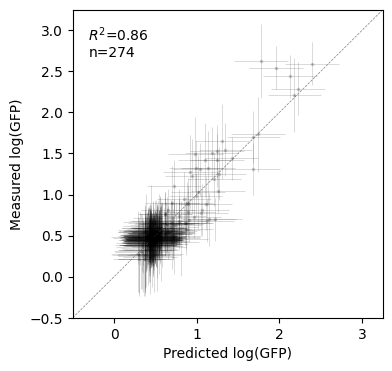

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
x, xerr = test["f"], 2 * test["f_std"]
y, yerr = test["y"], 2 * np.sqrt(test["y_var"])
lims = (-0.5, 3.25)
r2 = pearsonr(y, x)[0] ** 2
axes.errorbar(
    x,
    y,
    xerr=xerr,
    yerr=yerr,
    color="black",
    fmt="o",
    alpha=0.2,
    markeredgewidth=0,
    markersize=2.5,
    lw=0.5,
)
axes.set(
    xlim=lims,
    ylim=lims,
    xticks=np.arange(4),
    xlabel="Predicted log(GFP)",
    ylabel="Measured log(GFP)",
)
axes.axline((0, 0), (1, 1), lw=0.5, c="grey", linestyle="--")
axes.text(
    0.05,
    0.95,
    "$R^2$" + "={:.2f}\nn={}".format(r2, test.shape[0]),
    transform=axes.transAxes,
    va="top",
    ha="left",
)

Text(0.05, 0.95, '$R^2$=0.832')

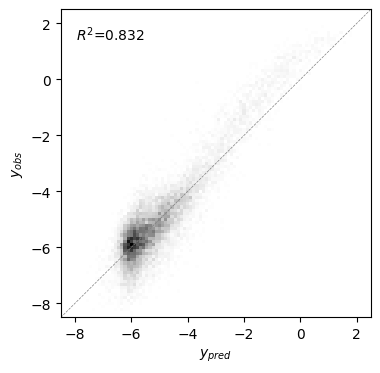

In [29]:
lim = (-9, 3)
r2 = pearsonr(mei.loc[X_test, 'y'], y_test)[0] ** 2
bins = np.linspace(lim[0] + 0.5, lim[1] - 0.5, 100)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes.hist2d(x=mei.loc[X_test, 'y'], y=y_test, cmap="binary", bins=bins)
axes.axline((0, 0), (1, 1), lw=0.5, linestyle="--", c="grey")
axes.set(
    xlabel=r"$y_{pred}$",
    ylabel=r"$y_{obs}$",
    xlim=(lim[0] + 0.5, lim[1] - 0.5),
    ylim=(lim[0] + 0.5, lim[1] - 0.5),
)
axes.text(
    0.05,
    0.95,
    r"$R^2$=" + "{:.3f}".format(r2),
    transform=axes.transAxes,
    color="black",
    ha="left",
    va="top",
)



### Estimating Variance Components

In [30]:
model = VCregression(seq_length=4, alphabet_type='protein')
model.fit(X=X_train, y=y_train, y_var=y_var_train)

In [31]:
lambdas = model.lambdas
x = np.arange(0, lambdas.shape[0])
variance = model.lambdas_to_variance(lambdas)
p_variance = variance / variance.sum() * 100

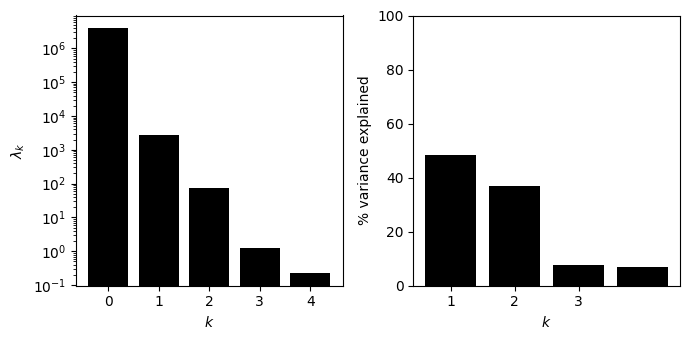

In [32]:
fig, subplots = init_fig(1, 2, colsize=3.5, rowsize=3.5)

axes = subplots[0]
axes.bar(x=x, height=lambdas, color='black')
axes.set(xlabel='$k$', ylabel='$\lambda_k$', yscale='log')

axes = subplots[1]
axes.bar(x=x[1:], height=p_variance, color='black')
axes.set(xlabel='$k$', ylabel='% variance explained', ylim=(0, 100), xticks=[1, 2, 3])

fig.tight_layout()

### Inferring the complete GB1 landscape

Now that we have inferred the variance components, we obtain inferences for the complete combinatorial landscape and check the prediction accuracy for the held-out test data. Moreover, we can also see the distribution of phenotypic values within and outside the data

In [33]:
pred = model.predict().join(data, lsuffix='_pred')
pred

,y_pred,y,y_var
AAAA,0.399348,0.460831,0.046009
AAAC,-2.551728,NaN,NaN
AAAD,-3.454428,NaN,NaN
AAAE,-4.783908,NaN,NaN
AAAF,-3.685388,NaN,NaN
...,...,...,...
YYYS,-4.822342,-5.269987,0.291090
YYYT,-3.635390,-3.821426,0.074489
YYYV,-3.123463,-3.143536,0.074682
YYYW,-4.837803,-4.306581,0.699467


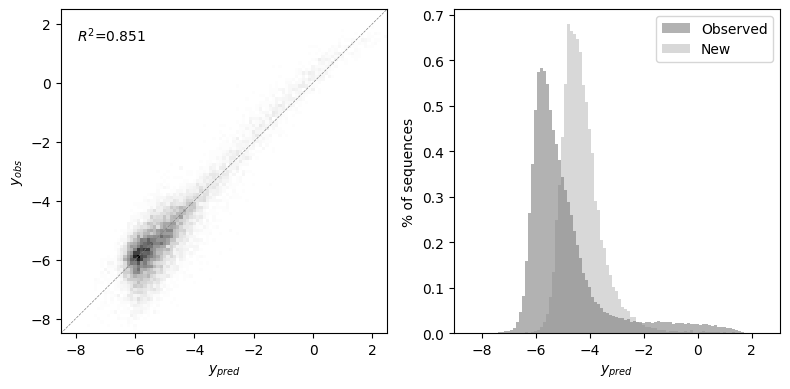

In [34]:
test = pred.loc[X_test, :]
r2 = pearsonr(test['y_pred'], test['y'])[0] ** 2
lim = (-9, 3)
bins = np.linspace(lim[0] + 0.5, lim[1] - 0.5, 100)

fig, subplots = plt.subplots(1, 2, figsize=(8, 4))

axes = subplots[0]
axes.hist2d(x=test['y_pred'], y=test['y'], cmap='binary', bins=bins)
axes.axline((0, 0), (1, 1), lw=0.5, linestyle='--', c='grey')
axes.set(xlabel=r'$y_{pred}$', ylabel=r'$y_{obs}$',
         xlim=(lim[0] + 0.5, lim[1] - 0.5),
         ylim=(lim[0] + 0.5, lim[1] - 0.5))
axes.text(0.05, 0.95, r'$R^2$=' + '{:.3f}'.format(r2),
          transform=axes.transAxes, color='black', ha='left', va='top')

axes = subplots[1]
axes.hist(pred.dropna()['y_pred'], label='Observed', alpha=0.3, density=True, bins=bins, color='black')
axes.hist(pred.loc[np.isnan(pred['y']), 'y_pred'], label='New', alpha=0.3, density=True, bins=bins, color='grey')
axes.set(xlabel=r'$y_{pred}$', ylabel='% of sequences')
axes.legend(loc=0)

fig.tight_layout()

### Estimating local epistatic coefficients under the prior

As previously shown, we are not only restricted to making calibrated predictions for previously uncharacterized or held out sequences, but we can also get calibrated estimates for linear combinations of them and use them to answer questions about specific mutational effects and how they change as we introduced more mutations.

One of the main interactions in the GB1 dataset is that taking place between positions 41 and 54. In the wild-type sequence VDGV, G41L is highly deleterious, but becomes advantageous in the presence of V54G. Now, we can use our model to compute the posterior distribution for this epistatic coefficient given the whole dataset. 

We can select the 4 relevant sequences and show their measurement values

In [35]:
seqs = ['VDGV', 'VDGG', 'VDLV', 'VDLG']
df = data.loc[seqs, :]
df

,y,y_var
VDGV,0.000000,0.000027
VDGG,0.334153,0.003038
VDLV,-3.512487,0.105615
VDLG,1.140357,0.013197


We then define the contrast matrices for the coefficients of interest: the single point mutational effects as well as the epistatic coefficient between them.

In [36]:
contrast_matrix = pd.DataFrame({'G41L'     : [-1,  0,  1,  0],
                                'V54G'     : [-1,  1,  0,  0],
                                'G41L:V54G': [ 1, -1, -1,  1]},
                                index=seqs)
contrast = model.make_contrasts(contrast_matrix)
contrast

100%|██████████| 3/3 [00:18<00:00,  6.08s/it]


,estimate,std,ci_95_lower,ci_95_upper,p(|x|>0)
G41L,-3.376735,0.277964,-3.932662,-2.820807,1.0
V54G,0.318694,0.055069,0.208557,0.428832,1.0
G41L:V54G,4.208261,0.303865,3.600531,4.815991,1.0


We can see that there is strong support in the posterior for the deleterious effect of G41L in the wild-type background, but also that this is strongly reversed in the presence of V54G. Lets now compare these estimates with the naive comparisons using the estimated measurement errors alone

In [37]:
make_contrasts(df, contrast_matrix)

,estimate,std,ci_95_lower,ci_95_upper,p(|x|>0)
G41L,-3.512487,0.325026,-4.162539,-2.862435,1.0
V54G,0.334153,0.055370,0.223413,0.444892,1.0
G41L:V54G,4.318691,0.349109,3.620472,5.016910,1.0


We can see how estimates are then shrunk towards 0 and uncertaintly is slightly reduced by using the prior that was estimated across the complete dataset